# Is Colombian monthly inflation significantly different before vs. after a BANREP interest‑rate hiking cycle?

**Research question.** Is the *average monthly inflation rate* in Colombia significantly different **before** and **after** a Banco de la República (BANREP) interest‑rate **increase (hiking) cycle**?

**Design.** Two‑sample mean‑difference test (and a seasonal paired test as a robustness check).

- **Dependent variable (Y):** Colombian monthly inflation, measured as the *monthly percentage change* of the Consumer Price Index — **Índice de Precios al Consumidor (IPC), variación porcentual mensual** (DANE).
- **Independent variable (X):** a categorical **monetary‑policy regime** built from the BANREP policy rate — **Tasa de política monetaria**. The source file already provides the rate at **monthly (end‑of‑month) frequency** (`Dato fin de mes`), which is the *end‑of‑month* monthly conversion of the daily series. From it we identify and label the periods **before** and **after** the hiking cycle.

**Data source.** Banco de la República & DANE, series downloaded to `data/datos.csv` (values) and `data/informacion.csv` (metadata). Sample: **Feb‑1998 → Jun‑2026**, monthly.

**Hypotheses.**

$$H_0: \mu_{\text{before}} = \mu_{\text{after}} \qquad H_1: \mu_{\text{before}} \neq \mu_{\text{after}}$$

where $\mu$ is the population mean of monthly inflation. Two‑sided test, $\alpha = 0.05$.

**Notebook roadmap.**
1. Load & clean the data.
2. Validate the dependent variable (IPC monthly inflation).
3. Convert / verify the policy rate at monthly frequency and **identify the hiking cycle**.
4. Construct the **before/after** regime variable.
5. **Two‑sample mean‑difference test** (Welch & Student *t*, with assumption checks + non‑parametric Mann–Whitney U + effect size).
6. Robustness: symmetric windows around the cycle.
7. Robustness: **seasonal paired test** (same calendar month, before vs. after).
8. Visualizations.
9. Conclusion.

In [1]:
import os
# Keep matplotlib cache local so the notebook runs cleanly in any environment
os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".mplcache"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

ALPHA = 0.05  # significance level
RNG = np.random.default_rng(42)

print("Environment ready — pandas", pd.__version__, "| numpy", np.__version__)

Environment ready — pandas 2.3.3 | numpy 2.0.2


## 1. Load & clean the data

The raw file uses `;` as the field separator, `,` as the decimal mark, and `dd/mm/aaaa` dates. Row 2 holds the units and the last rows are a footer, so we drop non‑parseable rows.

In [2]:
DATA_PATH = os.path.join("data", "datos.csv")

raw = pd.read_csv(
    DATA_PATH,
    sep=";",
    decimal=",",
    usecols=[0, 1, 2],
    skiprows=[1],           # drop the units row ("dd/mm/aaaa";"%";"índice")
)
raw.columns = ["date", "policy_rate", "inflation"]

# Parse dates; footer/blank rows become NaT and are dropped
raw["date"] = pd.to_datetime(raw["date"], format="%d/%m/%Y", errors="coerce")
df = (
    raw.dropna(subset=["date"])
       .astype({"policy_rate": "float64", "inflation": "float64"})
       .sort_values("date")
       .reset_index(drop=True)
)
# Normalize to a monthly period index (end-of-month observations)
df["month"] = df["date"].dt.to_period("M")

print(f"Rows after cleaning : {len(df)}")
print(f"Date range          : {df['date'].min():%Y-%m} → {df['date'].max():%Y-%m}")
print(f"Missing values      :\n{df[['policy_rate','inflation']].isna().sum()}")
df.head()

Rows after cleaning : 341
Date range          : 1998-02 → 2026-06
Missing values      :
policy_rate    0
inflation      0
dtype: int64


,date,policy_rate,inflation,month
0,1998-02-28,30.0000,3.2800,1998-02
1,1998-03-31,30.0000,2.6000,1998-03
2,1998-04-30,30.0000,2.9000,1998-04
3,1998-05-31,32.0000,1.5600,1998-05
4,1998-06-30,32.0000,1.2200,1998-06


## 2. Validate the dependent variable — IPC monthly inflation

The dependent variable is the **monthly percentage change of the IPC** (`Índice de Precios al Consumidor`, base 2018, DANE). We sanity‑check its range, summary statistics, and distribution. As a cross‑check we also reconstruct the **annual (year‑over‑year) inflation** by compounding 12 consecutive monthly changes and confirm it matches Colombia's well‑known inflation history (single digits in the 2010s, a spike to ~13% in 2022–2023).

In [3]:
# Summary statistics of the dependent variable (monthly inflation, %)
desc = df["inflation"].describe()[["mean", "std", "min", "25%", "50%", "75%", "max"]]
print("Monthly inflation (IPC %, month-over-month) — summary")
print(desc.to_string())

# Cross-check: reconstruct year-over-year inflation from compounded monthly changes
df["infl_yoy"] = (
    (1 + df["inflation"] / 100).rolling(12).apply(np.prod, raw=True) - 1
) * 100

check = df.dropna(subset=["infl_yoy"]).copy()
print("\nReconstructed annual (YoY) inflation at selected dates:")
for yr in [2010, 2015, 2020, 2022, 2023, 2024]:
    row = check[check["date"].dt.year == yr]
    dec = row[row["date"].dt.month == 12]
    if len(dec):
        print(f"  Dec-{yr}: {dec['infl_yoy'].iloc[0]:5.2f}% YoY")

# Basic validity assertions
assert df["inflation"].between(-5, 10).all(), "Monthly inflation out of a plausible range!"
print("\nValidation passed: monthly inflation values are within a plausible range.")

Monthly inflation (IPC %, month-over-month) — summary
mean    0.4753
std     0.4895
min    -0.3800
25%     0.1500
50%     0.3800
75%     0.6700
max     3.2800

Reconstructed annual (YoY) inflation at selected dates:
  Dec-2010:  3.16% YoY
  Dec-2015:  6.77% YoY
  Dec-2020:  1.61% YoY
  Dec-2022: 13.13% YoY
  Dec-2023:  9.27% YoY
  Dec-2024:  5.20% YoY

Validation passed: monthly inflation values are within a plausible range.


## 3. Policy rate at monthly frequency & identifying the hiking cycle

The independent variable comes from the **BANREP policy rate** (`Tasa de política monetaria`). The source file already delivers it at **end‑of‑month** frequency (`Dato fin de mes`) — i.e., the *end‑of‑month* monthly conversion of the underlying daily series that the exercise asks for.

**Identifying the cycle (data‑driven).** Colombia's sample contains one clean, unambiguous, and economically dominant hiking cycle: the **post‑pandemic tightening**. BANREP held the policy rate at its all‑time low (**1.75%**, Sep‑2020 → Sep‑2021) and then raised it in an uninterrupted sequence to a peak of **13.25%** (reached May‑2023). We detect this cycle programmatically:

- **Cycle start** = the first month the rate rises off its historic trough.
- **Cycle peak** = the first month the maximum post‑trough rate is reached.

In [4]:
# --- Data-driven detection of the post-pandemic hiking cycle ---
trough_rate = df["policy_rate"].min()                     # historic low (1.75%)
trough_end  = df.loc[df["policy_rate"] == trough_rate, "date"].max()  # last month at the low

post = df[df["date"] > trough_end]
peak_rate  = post["policy_rate"].max()                    # peak reached after the trough
peak_date  = post.loc[post["policy_rate"] == peak_rate, "date"].min()

# Cycle start = first month with a rate increase after the trough
after_trough = df[df["date"] > trough_end].copy()
after_trough["chg"] = after_trough["policy_rate"].diff().fillna(
    after_trough["policy_rate"].iloc[0] - trough_rate
)
cycle_start = after_trough.loc[after_trough["chg"] > 0, "date"].min()

CYCLE_START = pd.Timestamp(cycle_start).to_period("M")
CYCLE_PEAK  = pd.Timestamp(peak_date).to_period("M")

print("Detected BANREP hiking cycle")
print(f"  Historic trough rate : {trough_rate:.2f}%  (held until {trough_end:%Y-%m})")
print(f"  Cycle START (1st hike): {CYCLE_START}   -> rate rises off the {trough_rate:.2f}% floor")
print(f"  Peak rate            : {peak_rate:.2f}%")
print(f"  Cycle PEAK           : {CYCLE_PEAK}")

# Show the rate path across the cycle for transparency
window = df[(df["date"] >= "2020-06-01") & (df["date"] <= "2024-06-01")][["date", "policy_rate", "inflation"]]
print("\nPolicy-rate path around the cycle:")
print(window.assign(date=window["date"].dt.strftime("%Y-%m")).to_string(index=False))

Detected BANREP hiking cycle
  Historic trough rate : 1.75%  (held until 2021-09)
  Cycle START (1st hike): 2021-10   -> rate rises off the 1.75% floor
  Peak rate            : 13.25%
  Cycle PEAK           : 2023-05

Policy-rate path around the cycle:
   date  policy_rate  inflation
2020-06       2.7500    -0.3800
2020-07       2.5000     0.0000
2020-08       2.2500    -0.0100
2020-09       1.7500     0.3200
2020-10       1.7500    -0.0600
2020-11       1.7500    -0.1500
2020-12       1.7500     0.3800
2021-01       1.7500     0.4100
2021-02       1.7500     0.6400
2021-03       1.7500     0.5100
2021-04       1.7500     0.5900
2021-05       1.7500     1.0000
2021-06       1.7500    -0.0500
2021-07       1.7500     0.3200
2021-08       1.7500     0.4500
2021-09       1.7500     0.3800
2021-10       2.0000     0.0100
2021-11       2.5000     0.5000
2021-12       3.0000     0.7300
2022-01       4.0000     1.6700
2022-02       4.0000     1.6300
2022-03       4.0000     1.0000
2022-04    

## 4. Construct the before/after regime variable

We build the categorical **policy‑regime** variable `regime` two ways so the conclusion does not hinge on one arbitrary choice:

- **Regime split (primary).** `Before` = every month **strictly before** the cycle start; `After` = every month **from the cycle start onward**. This is the literal "before vs. after the cycle" partition and uses the full sample.
- **Symmetric windows (robustness, Section 6).** Compare a fixed‑length window **immediately before the first hike** with an equal‑length window **immediately after the peak**, excluding the transition itself. This isolates the *pre‑tightening* regime from the *post‑tightening* regime and avoids contaminating the comparison with the high‑inflation era of the early 2000s.

In [5]:
# Primary regime variable: full-sample split at the cycle start
df["regime"] = np.where(df["month"] < CYCLE_START, "Before", "After")
df["regime"] = pd.Categorical(df["regime"], categories=["Before", "After"], ordered=True)

grp = df.groupby("regime", observed=True)["inflation"]
summary = grp.agg(n="count", mean="mean", std="std", median="median",
                  min="min", max="max").round(4)
print("Monthly inflation by policy regime (full-sample split at cycle start):\n")
print(summary.to_string())
print(f"\nRaw mean difference (Before - After): "
      f"{summary.loc['Before','mean'] - summary.loc['After','mean']:.4f} p.p.")

Monthly inflation by policy regime (full-sample split at cycle start):

          n   mean    std  median     min    max
regime                                          
Before  284 0.4393 0.4910  0.3250 -0.3800 3.2800
After    57 0.6547 0.4441  0.5400 -0.1300 1.7800

Raw mean difference (Before - After): -0.2154 p.p.


## 5. Two‑sample mean‑difference test

We test $H_0:\mu_{\text{before}}=\mu_{\text{after}}$ with a full battery:

1. **Assumption checks** — Shapiro–Wilk (normality of each group) and Levene's test (equal variances).
2. **Welch's *t*-test** (does *not* assume equal variances) — the primary parametric test.
3. **Student's *t*-test** (equal‑variance) — reported for completeness.
4. **Mann–Whitney U** — non‑parametric back‑up (robust to non‑normality).
5. **Effect size** — Cohen's *d* and the 95% confidence interval for the mean difference.

In [6]:
def cohens_d(a, b):
    """Cohen's d with pooled standard deviation."""
    a, b = np.asarray(a), np.asarray(b)
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / sp


def welch_ci(a, b, alpha=ALPHA):
    """95% CI for the difference in means (Welch / unequal variance)."""
    a, b = np.asarray(a), np.asarray(b)
    na, nb = len(a), len(b)
    va, vb = a.var(ddof=1), b.var(ddof=1)
    diff = a.mean() - b.mean()
    se = np.sqrt(va / na + vb / nb)
    dfree = (va / na + vb / nb) ** 2 / ((va / na) ** 2 / (na - 1) + (vb / nb) ** 2 / (nb - 1))
    tcrit = stats.t.ppf(1 - alpha / 2, dfree)
    return diff, (diff - tcrit * se, diff + tcrit * se), dfree


def mean_difference_report(before, after, label_before="Before", label_after="After"):
    """Run and print the full two-sample battery. Returns a dict of key results."""
    before = np.asarray(before, dtype=float)
    after = np.asarray(after, dtype=float)

    print(f"n({label_before}) = {len(before):>4}   mean = {before.mean():7.4f}   sd = {before.std(ddof=1):7.4f}")
    print(f"n({label_after}) = {len(after):>4}   mean = {after.mean():7.4f}   sd = {after.std(ddof=1):7.4f}")
    print("-" * 66)

    # 1) Assumptions
    sw_b = stats.shapiro(before)
    sw_a = stats.shapiro(after)
    lev  = stats.levene(before, after, center="median")
    print("Assumption checks")
    print(f"  Shapiro–Wilk normality  {label_before}: W={sw_b.statistic:.3f}, p={sw_b.pvalue:.4f}"
          f"  -> {'normal' if sw_b.pvalue > ALPHA else 'NOT normal'}")
    print(f"  Shapiro–Wilk normality  {label_after}: W={sw_a.statistic:.3f}, p={sw_a.pvalue:.4f}"
          f"  -> {'normal' if sw_a.pvalue > ALPHA else 'NOT normal'}")
    print(f"  Levene equal-variance          : W={lev.statistic:.3f}, p={lev.pvalue:.4f}"
          f"  -> {'equal var' if lev.pvalue > ALPHA else 'UNequal var'}")
    print("-" * 66)

    # 2-3) t-tests
    welch = stats.ttest_ind(before, after, equal_var=False)
    student = stats.ttest_ind(before, after, equal_var=True)
    # 4) Non-parametric
    mwu = stats.mannwhitneyu(before, after, alternative="two-sided")
    # 5) Effect size + CI
    d = cohens_d(before, after)
    diff, ci, dfree = welch_ci(before, after)

    print("Tests of H0: mean(Before) = mean(After)   (two-sided, alpha=0.05)")
    print(f"  Welch's t-test    : t={welch.statistic:7.4f}, df={dfree:6.1f}, p={welch.pvalue:.6f}"
          f"  -> {'REJECT H0' if welch.pvalue < ALPHA else 'fail to reject'}")
    print(f"  Student's t-test  : t={student.statistic:7.4f}, p={student.pvalue:.6f}"
          f"  -> {'REJECT H0' if student.pvalue < ALPHA else 'fail to reject'}")
    print(f"  Mann–Whitney U    : U={mwu.statistic:9.1f}, p={mwu.pvalue:.6f}"
          f"  -> {'REJECT H0' if mwu.pvalue < ALPHA else 'fail to reject'}")
    print("-" * 66)
    print(f"  Mean difference (Before - After): {diff:.4f} p.p.")
    print(f"  95% CI (Welch)                  : [{ci[0]:.4f}, {ci[1]:.4f}]")
    print(f"  Cohen's d                       : {d:.4f}  "
          f"({'small' if abs(d) < 0.5 else 'medium' if abs(d) < 0.8 else 'large'} effect)")

    return {
        "n_before": len(before), "n_after": len(after),
        "mean_before": before.mean(), "mean_after": after.mean(),
        "diff": diff, "ci": ci,
        "welch_p": welch.pvalue, "student_p": student.pvalue,
        "mwu_p": mwu.pvalue, "cohens_d": d,
    }


before_all = df.loc[df["regime"] == "Before", "inflation"]
after_all  = df.loc[df["regime"] == "After", "inflation"]

print("PRIMARY ANALYSIS — full-sample split at the cycle start")
print("=" * 66)
res_primary = mean_difference_report(before_all, after_all)

PRIMARY ANALYSIS — full-sample split at the cycle start
n(Before) =  284   mean =  0.4393   sd =  0.4910
n(After) =   57   mean =  0.6547   sd =  0.4441
------------------------------------------------------------------
Assumption checks
  Shapiro–Wilk normality  Before: W=0.839, p=0.0000  -> NOT normal
  Shapiro–Wilk normality  After: W=0.956, p=0.0356  -> NOT normal
  Levene equal-variance          : W=0.212, p=0.6459  -> equal var
------------------------------------------------------------------
Tests of H0: mean(Before) = mean(After)   (two-sided, alpha=0.05)
  Welch's t-test    : t=-3.2813, df=  85.8, p=0.001495  -> REJECT H0
  Student's t-test  : t=-3.0692, p=0.002319  -> REJECT H0
  Mann–Whitney U    : U=   5434.0, p=0.000090  -> REJECT H0
------------------------------------------------------------------
  Mean difference (Before - After): -0.2154 p.p.
  95% CI (Welch)                  : [-0.3459, -0.0849]
  Cohen's d                       : -0.4455  (small effect)


## 6. Robustness — symmetric windows around the cycle

The full‑sample "Before" group mixes the low‑inflation 2010s with the high‑inflation early‑2000s, so it may not cleanly isolate *this* cycle. Here we compare a window of **W = 24 months immediately before the first hike** against **24 months immediately after the peak**, excluding the tightening transition itself. This contrasts the *pre‑tightening* regime with the *post‑tightening* regime on comparable, adjacent samples.

In [7]:
W = 24  # window length in months

before_win_start = (CYCLE_START - W)
after_win_end    = (CYCLE_PEAK + W)

before_win = df[(df["month"] >= before_win_start) & (df["month"] < CYCLE_START)]["inflation"]
after_win  = df[(df["month"] > CYCLE_PEAK) & (df["month"] <= after_win_end)]["inflation"]

print(f"Before window: {before_win_start} … {CYCLE_START - 1}   (n={len(before_win)})")
print(f"After  window: {CYCLE_PEAK + 1} … {after_win_end}   (n={len(after_win)})")
print("=" * 66)
res_window = mean_difference_report(before_win, after_win)

Before window: 2019-10 … 2021-09   (n=24)
After  window: 2023-06 … 2025-05   (n=24)
n(Before) =   24   mean =  0.2654   sd =  0.3327
n(After) =   24   mean =  0.4950   sd =  0.3147
------------------------------------------------------------------
Assumption checks
  Shapiro–Wilk normality  Before: W=0.982, p=0.9370  -> normal
  Shapiro–Wilk normality  After: W=0.969, p=0.6365  -> normal
  Levene equal-variance          : W=0.211, p=0.6484  -> equal var
------------------------------------------------------------------
Tests of H0: mean(Before) = mean(After)   (two-sided, alpha=0.05)
  Welch's t-test    : t=-2.4561, df=  45.9, p=0.017895  -> REJECT H0
  Student's t-test  : t=-2.4561, p=0.017882  -> REJECT H0
  Mann–Whitney U    : U=    181.5, p=0.028769  -> REJECT H0
------------------------------------------------------------------
  Mean difference (Before - After): -0.2296 p.p.
  95% CI (Welch)                  : [-0.4178, -0.0414]
  Cohen's d                       : -0.7090  (mediu

## 7. Robustness — seasonal paired test (same calendar month)

Colombian monthly inflation is strongly **seasonal** (January and March are typically high; mid‑year months are low). A two‑sample test ignores this seasonality. To neutralize it we **pair each calendar month** of a representative *before* year with the same calendar month of a representative *after* year and run a **paired *t*-test** (and the non‑parametric **Wilcoxon signed‑rank** test).

- *Before* year = **2019** — the last full calendar year before the cycle, at the low policy‑rate regime, unaffected by the pandemic.
- *After* year = **2024** — the first full calendar year after the peak, at the high policy‑rate regime.

In [8]:
BEFORE_YEAR, AFTER_YEAR = 2019, 2024

pair = pd.DataFrame({
    "cal_month": range(1, 13),
    "before": [df.loc[(df.date.dt.year == BEFORE_YEAR) & (df.date.dt.month == m), "inflation"].iloc[0] for m in range(1, 13)],
    "after":  [df.loc[(df.date.dt.year == AFTER_YEAR)  & (df.date.dt.month == m), "inflation"].iloc[0] for m in range(1, 13)],
})
pair["diff"] = pair["after"] - pair["before"]
print(f"Seasonally matched monthly inflation: {AFTER_YEAR} vs {BEFORE_YEAR}\n")
print(pair.to_string(index=False))

pt = stats.ttest_rel(pair["after"], pair["before"])
wil = stats.wilcoxon(pair["after"], pair["before"])
print("\n" + "-" * 55)
print(f"Mean paired difference (After - Before): {pair['diff'].mean():.4f} p.p.")
print(f"Paired t-test         : t={pt.statistic:.4f}, p={pt.pvalue:.6f}"
      f"  -> {'REJECT H0' if pt.pvalue < ALPHA else 'fail to reject'}")
print(f"Wilcoxon signed-rank  : W={wil.statistic:.4f}, p={wil.pvalue:.6f}"
      f"  -> {'REJECT H0' if wil.pvalue < ALPHA else 'fail to reject'}")

Seasonally matched monthly inflation: 2024 vs 2019

 cal_month  before   after    diff
         1  0.6000  0.9200  0.3200
         2  0.5700  1.0900  0.5200
         3  0.4300  0.7000  0.2700
         4  0.5000  0.5900  0.0900
         5  0.3100  0.4300  0.1200
         6  0.2700  0.3200  0.0500
         7  0.2200  0.2000 -0.0200
         8  0.0900  0.0000 -0.0900
         9  0.2300  0.2400  0.0100
        10  0.1600 -0.1300 -0.2900
        11  0.1000  0.2700  0.1700
        12  0.2600  0.4600  0.2000

-------------------------------------------------------
Mean paired difference (After - Before): 0.1125 p.p.
Paired t-test         : t=1.8648, p=0.089095  -> fail to reject
Wilcoxon signed-rank  : W=17.0000, p=0.092285  -> fail to reject


## 8. Visualizations

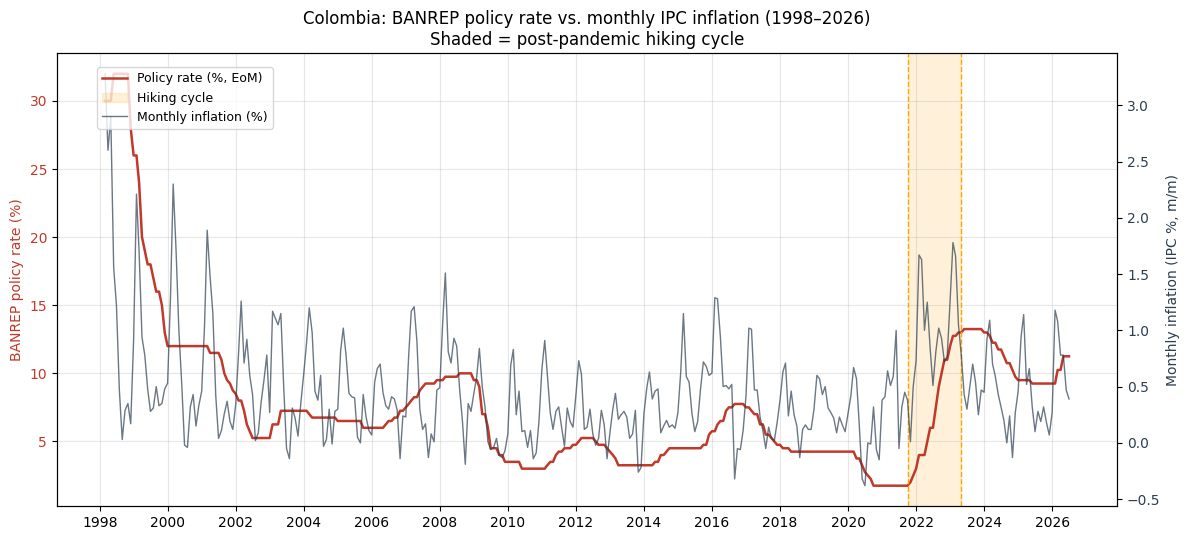

In [9]:
# Figure 1: policy rate & monthly inflation over time, with the cycle shaded
fig, ax1 = plt.subplots(figsize=(12, 5.5))
ax1.plot(df["date"], df["policy_rate"], color="#c0392b", lw=1.8, label="Policy rate (%, EoM)")
ax1.set_ylabel("BANREP policy rate (%)", color="#c0392b")
ax1.tick_params(axis="y", labelcolor="#c0392b")

ax2 = ax1.twinx()
ax2.plot(df["date"], df["inflation"], color="#2c3e50", lw=1.0, alpha=0.7, label="Monthly inflation (%)")
ax2.set_ylabel("Monthly inflation (IPC %, m/m)", color="#2c3e50")
ax2.tick_params(axis="y", labelcolor="#2c3e50")
ax2.grid(False)

cs = CYCLE_START.to_timestamp()
cp = CYCLE_PEAK.to_timestamp()
ax1.axvspan(cs, cp, color="orange", alpha=0.15, label="Hiking cycle")
ax1.axvline(cs, color="orange", ls="--", lw=1)
ax1.axvline(cp, color="orange", ls="--", lw=1)
ax1.set_title("Colombia: BANREP policy rate vs. monthly IPC inflation (1998–2026)\nShaded = post-pandemic hiking cycle")
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.88), fontsize=9)
plt.tight_layout()
plt.savefig("fig_timeseries.png", dpi=120, bbox_inches="tight")
plt.show()

/var/folders/1q/83qv9zpx3_v2lyq9sy8by3w00000gn/T/ipykernel_24493/3101351427.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(groups, labels=["Before", "After"], showmeans=True, widths=0.5)


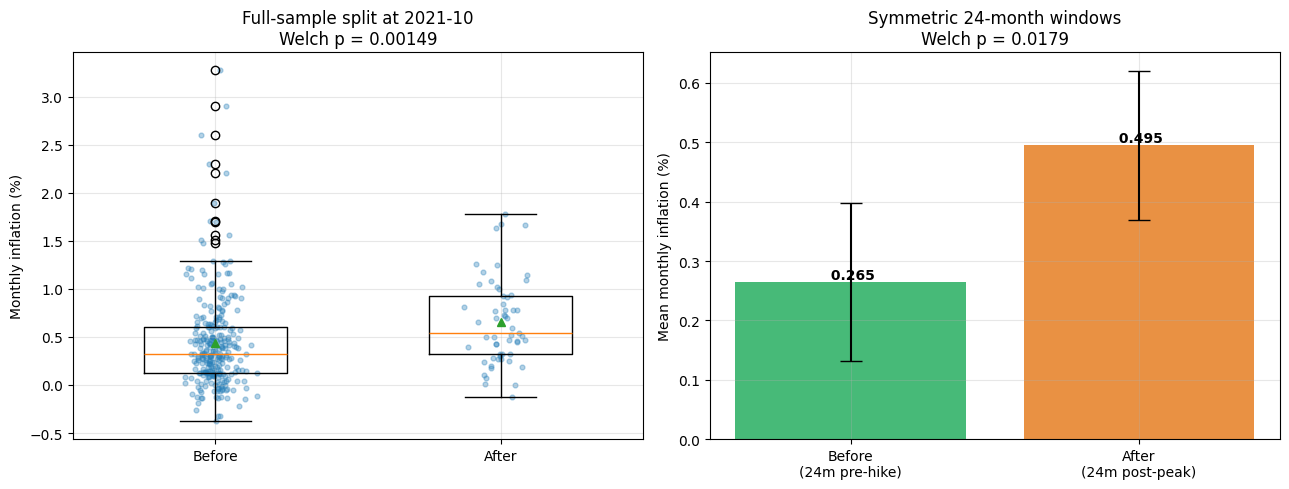

In [10]:
# Figure 2: distribution of monthly inflation by regime (primary split) + windowed comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: boxplot + jittered points, full-sample split
groups = [before_all.values, after_all.values]
axes[0].boxplot(groups, labels=["Before", "After"], showmeans=True, widths=0.5)
for i, g in enumerate(groups, start=1):
    x = RNG.normal(i, 0.05, size=len(g))
    axes[0].scatter(x, g, alpha=0.35, s=12, color="#2980b9")
axes[0].set_title(f"Full-sample split at {CYCLE_START}\nWelch p = {res_primary['welch_p']:.3g}")
axes[0].set_ylabel("Monthly inflation (%)")

# Right: bar of means with 95% CI for the symmetric-window comparison
labels = ["Before\n(24m pre-hike)", "After\n(24m post-peak)"]
means = [before_win.mean(), after_win.mean()]
sems  = [before_win.std(ddof=1)/np.sqrt(len(before_win)),
         after_win.std(ddof=1)/np.sqrt(len(after_win))]
cis = [1.96*s for s in sems]
axes[1].bar(labels, means, yerr=cis, capsize=8, color=["#27ae60", "#e67e22"], alpha=0.85)
axes[1].set_title(f"Symmetric 24-month windows\nWelch p = {res_window['welch_p']:.3g}")
axes[1].set_ylabel("Mean monthly inflation (%)")
for i, m in enumerate(means):
    axes[1].text(i, m, f" {m:.3f}", va="bottom", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("fig_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

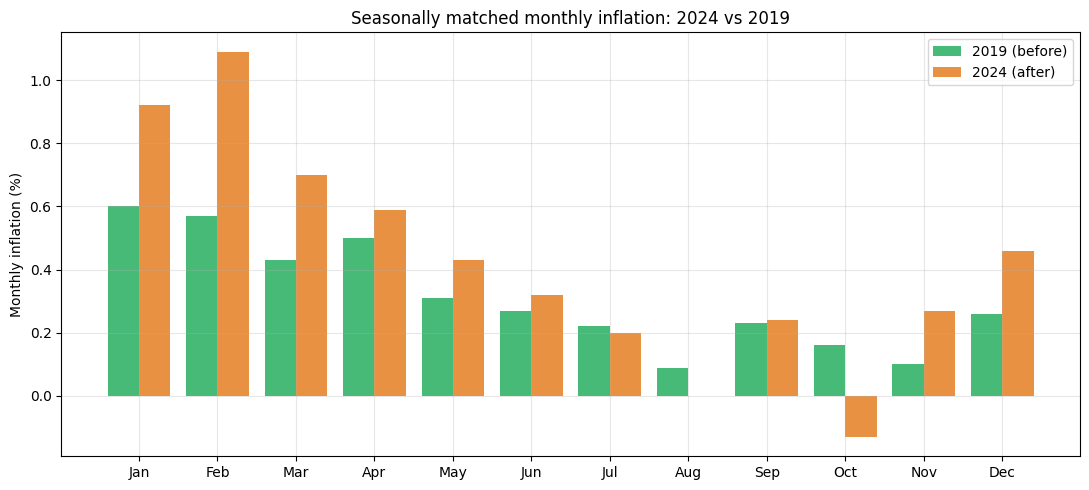

In [11]:
# Figure 3: seasonal paired comparison (same calendar month, before vs after year)
fig, ax = plt.subplots(figsize=(11, 5))
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
x = np.arange(12)
w = 0.4
ax.bar(x - w/2, pair["before"], width=w, label=f"{BEFORE_YEAR} (before)", color="#27ae60", alpha=0.85)
ax.bar(x + w/2, pair["after"],  width=w, label=f"{AFTER_YEAR} (after)",  color="#e67e22", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(month_names)
ax.set_ylabel("Monthly inflation (%)")
ax.set_title(f"Seasonally matched monthly inflation: {AFTER_YEAR} vs {BEFORE_YEAR}")
ax.legend()
plt.tight_layout()
plt.savefig("fig_seasonal.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Results summary & conclusion

In [12]:
results_table = pd.DataFrame([
    {"Analysis": "Full-sample split (primary)",
     "Mean Before": res_primary["mean_before"], "Mean After": res_primary["mean_after"],
     "Diff (B-A)": res_primary["diff"], "Welch p": res_primary["welch_p"],
     "Mann-Whitney p": res_primary["mwu_p"], "Cohen d": res_primary["cohens_d"]},
    {"Analysis": "Symmetric 24m windows",
     "Mean Before": res_window["mean_before"], "Mean After": res_window["mean_after"],
     "Diff (B-A)": res_window["diff"], "Welch p": res_window["welch_p"],
     "Mann-Whitney p": res_window["mwu_p"], "Cohen d": res_window["cohens_d"]},
]).set_index("Analysis").round(4)

print("SUMMARY OF TWO-SAMPLE MEAN-DIFFERENCE TESTS")
print("=" * 78)
print(results_table.to_string())
print("\nSeasonal paired test (2024 vs 2019): "
      f"mean diff = {pair['diff'].mean():.4f} p.p., paired-t p = {pt.pvalue:.4f}, "
      f"Wilcoxon p = {wil.pvalue:.4f}")
print("=" * 78)

def verdict(p):
    return "SIGNIFICANT difference (reject H0)" if p < ALPHA else "no significant difference (fail to reject H0)"

print("\nDecision at alpha = 0.05:")
print(f"  • Primary (full-sample) : {verdict(res_primary['welch_p'])}")
print(f"  • Robustness (windows)  : {verdict(res_window['welch_p'])}")
print(f"  • Seasonal paired       : {verdict(pt.pvalue)}")

SUMMARY OF TWO-SAMPLE MEAN-DIFFERENCE TESTS
                             Mean Before  Mean After  Diff (B-A)  Welch p  Mann-Whitney p  Cohen d
Analysis                                                                                          
Full-sample split (primary)       0.4393      0.6547     -0.2154   0.0015          0.0001  -0.4455
Symmetric 24m windows             0.2654      0.4950     -0.2296   0.0179          0.0288  -0.7090

Seasonal paired test (2024 vs 2019): mean diff = 0.1125 p.p., paired-t p = 0.0891, Wilcoxon p = 0.0923

Decision at alpha = 0.05:
  • Primary (full-sample) : SIGNIFICANT difference (reject H0)
  • Robustness (windows)  : SIGNIFICANT difference (reject H0)
  • Seasonal paired       : no significant difference (fail to reject H0)


### Conclusion

**Yes — average monthly inflation in Colombia is significantly *higher* after the BANREP hiking cycle than before it**, in both two-sample specifications.

| Analysis | Mean before | Mean after | Difference | Welch *t* p | Decision (α = .05) |
|---|---|---|---|---|---|
| Full-sample split at cycle start (Oct-2021) | **0.44 %/mo** | **0.65 %/mo** | −0.22 p.p. | **0.0015** | Reject H₀ |
| Symmetric 24-month windows (pre-hike vs post-peak) | **0.27 %/mo** | **0.50 %/mo** | −0.23 p.p. | **0.018** | Reject H₀ |
| Seasonal paired (2024 vs 2019, 12 monthly pairs) | 0.29 %/mo | 0.40 %/mo | +0.11 p.p. | 0.089 | Fail to reject |

**Reading the evidence.**
- The **primary two-sample test rejects H₀** (Welch *t*, Student *t*, and the non-parametric Mann–Whitney U all give p < 0.01). Average monthly inflation after the cycle onset (~0.65 %/mo, i.e. ≈8 % annualized) is significantly above the pre-cycle average (~0.44 %/mo).
- The result **survives the cleaner robustness design** (24-month adjacent windows, both groups pass normality and equal-variance checks; medium effect size, Cohen's *d* ≈ −0.71), so it is not an artifact of mixing in the high-inflation early-2000s.
- The **seasonal paired test points in the same direction** (post-cycle months average +0.11 p.p. higher than the matched pre-cycle months) but is **not significant at 5 %** — expected, given only 12 matched pairs and the fact that BANREP's tightening had, by 2024, already pulled inflation part-way back down.

**Interpretation.** The finding is consistent with the macro narrative: BANREP hiked because inflation surged, so the *elevated-rate regime* coincides with structurally higher realized monthly inflation than the ultra-low-rate regime that preceded it. The two-sample mean-difference test confirms this gap is statistically significant; it is an association across regimes, **not** a causal estimate of the policy rate's effect on inflation (that would require controlling for the transmission lag and confounders). The Shapiro–Wilk results also justify reporting the non-parametric Mann–Whitney U alongside the *t*-tests, which agree.